# Load environment and libraries

In [ ]:
#@title Install basic packages and load environments. Initialize loaders for Snowflake and Google Sheets

!pip install "sphinx==7.2.6" > /dev/null

try:  # are we running on Colab?
  from google.colab import drive
  from google.colab import userdata
  colab = True
except Exception as e:
  colab = False

if colab:
  # install AWS CLI and dotenv
  !pip install "awscli==1.40.9" "python-dotenv==1.1.0" "gspread==6.2.0" > /dev/null

  import dotenv
  from getpass import getpass
  import os
  import gspread
  import base64
  import json
  import pandas as pd
  import numpy as np
  import base64
  from datetime import timedelta
  import sys

  import logging
  logging.basicConfig()
  logging.getLogger('snowflake').setLevel(logging.ERROR)

  import warnings
  warnings.filterwarnings('ignore')

  # mount Google Drive
  drive.mount("/content/gdrive")
  root_dir = "/content/gdrive/"
  project_drive = f"Shareddrives/Clarity AI/05 - Product Research & Innovation/21 - Team Lifecycle/11 - SME Repository/Colab setup"
  home_dir = f"{root_dir}MyDrive/Colab Notebooks/"
  sys.path.append(home_dir)

  # Configure AWS CLI credentials
  aws_dir = f"{os.getenv('HOME')}/.aws"
  os.makedirs(aws_dir, exist_ok=True)

  with open(f"{aws_dir}/credentials", "wt") as file:
    file.write(
  f"""[root]
  aws_access_key_id={userdata.get("AWS_ACCESS_KEY_ID")}
  aws_secret_access_key={userdata.get("AWS_SECRET_ACCESS_KEY")}
  """
    )
  with open(f"{aws_dir}/config", "wt") as file:
    file.write(
  f"""[profile mgmt]
  region=eu-central-1
  source_profile = root
  role_arn = arn:aws:iam::913932804865:role/federateclarity
  output=json
  [profile federate_root]
  region = eu-central-1
  source_profile = root
  role_arn = arn:aws:iam::064436394451:role/federateclarity
  """
    )
  os.environ["AWS_PROFILE"] = "mgmt"
  dotenv.load_dotenv(dotenv_path=f"{home_dir}.env")
  !pip install "boto3==1.38.10" "s3transfer>=0.12.0" "snowflake-connector-python==3.15.0" "snowflake-sqlalchemy==1.7.3" "numpy==2.0.2" "s3fs==0.4.2" "docutils==0.19" "pandas==2.2.2" "s3transfer>=0.12.0" > /dev/null


## SNOWFLAKE ##
# Import dependencies
import snowflake.connector as sc
from cryptography.hazmat.backends import default_backend
from sqlalchemy import create_engine, engine, text
from cryptography.hazmat.primitives import serialization
from sqlalchemy.dialects import registry

# Read certificate
try:
  with open("/content/gdrive/MyDrive/Colab Notebooks/private.pem", "rb") as key:
      private_key = serialization.load_pem_private_key(
          key.read(),
          password=userdata.get('certificatepass').encode(),
          backend=default_backend()
      )
except:
  with open("/content/gdrive/MyDrive/Colab_Notebooks/private.pem", "rb") as key:
      private_key = serialization.load_pem_private_key(
          key.read(),
          password=userdata.get('certificatepass').encode(),
          backend=default_backend()
      )
private_key_bytes = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

# Connect, create functions
class Snowflake:

  def __init__(self):
      self.engine = engine.create_engine("snowflake://not@used/db", creator=self.snow_connect)

  def snow_connect(self):
    return sc.connect(
            user=os.getenv("SNOWFLAKE_USERNAME"),
            account=os.getenv("SNOWFLAKE_ACCOUNT"),
            private_key=private_key_bytes,
            role=os.getenv("SNOWFLAKE_ROLE"),
            database=os.getenv("SNOWFLAKE_DATABASE"),
            warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
            )

  def read_sql_query(self, query):
    """
    Execute a query in Snowflake

    Args:
        query (str): SQL query to execute

    Returns:
        df (pd.DataFrame): DataFrame with the results of the query
    """
    with self.engine.begin() as connection:
        df = Snowflake().read_sql_query(text(query), con=connection)

    # Make sure all column names are lowercase
    df.columns = df.columns.str.lower()
    return df


## Initialize
snowflake_connector = Snowflake()

In [ ]:
#@title Google spreadsheets alternate connector

from google.colab import auth
from google.auth import default
try:
  import gspread
except ModuleNotFoundError:
  if 'google.colab' in str(get_ipython()):
    %pip install gspread
  import gspread
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

#Use these functions to read/write

def read_gsheet(spreadsheet_id, sheet_name,first_row_as_column_names=True):
  sht1 = gc.open_by_key(spreadsheet_id)
  worksheet = sht1.worksheet(sheet_name)
  df = pd.DataFrame(worksheet.get_all_values())
  if first_row_as_column_names == True:
    new_header = df.iloc[0]  # Take the first row as the header
    df = df[1:]  # Remove the first row from the dataframe
    df.columns = new_header
  return df


def write_gsheet(spreadsheet_id, sheet_name, df, range=None, clean=True):
  sht1 = gc.open_by_key(spreadsheet_id)
  try:
    worksheet = sht1.worksheet(sheet_name)
  except BaseException:
    worksheet = sht1.add_worksheet(sheet_name,"999","20")
  if clean:
    worksheet.clear()

  values_list = df.values.tolist()
  df=df.fillna('')

  if range == None:
    worksheet.update([df.columns.tolist()]+ df.values.tolist())
  elif range != None:
    worksheet.update(range, [df.columns.tolist()]+ df.values.tolist())

In [ ]:
class Snowflake:

    def __init__(self):
        self.engine = engine.create_engine(
            "snowflake://not@used/db",
            creator=self.snow_connect
        )

    def snow_connect(self):
        return sc.connect(
            user=os.getenv("SNOWFLAKE_USERNAME"),
            account=os.getenv("SNOWFLAKE_ACCOUNT"),
            private_key=private_key_bytes,
            role=os.getenv("SNOWFLAKE_ROLE"),
            database=os.getenv("SNOWFLAKE_DATABASE"),
            warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
        )

    def read_sql_query(self, query: str):
        """
        Execute a query in Snowflake and return results as a pandas DataFrame
        """
        with self.engine.begin() as connection:
            df = pd.read_sql_query(text(query), con=connection)

        # Make sure all column names are lowercase
        df.columns = df.columns.str.lower()
        return df

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [ ]:
#@title Import libraries and define functions needed to read the  registry service

import requests
import asyncio # only for async requests
import nest_asyncio
from google.colab import userdata
import json
import pandas as pd

def extract_registry_service_data(release_tag,use_release_candidate_tag=False):

  uri_base = 'https://registry-service.mgmt.clarity.ai/v1'

  headers = {"Authorization": "Bearer {}".format(userdata.get('registry_service_bearer_token'))}

  if use_release_candidate_tag:
    uri = uri_base + '/tags/'+ release_candidate

  else:
    uri = uri_base + '/tags/'+ release_tag


  params = {
      'tenant': 'CLA'
  }

  tags = requests.get(uri, params = params, headers = headers)

  tags.json()['tag']

  current_tag = tags.json()['tag']

  uri = uri_base + '/tags/{}'.format(current_tag)

  params = {
  }

  tables = requests.get(uri, params = params, headers = headers)

  tables=tables.json()['datasets']

  registry_service=pd.DataFrame(tables)

  registry_service_data=registry_service[['table_name','dataset_name','location','dag_owner','execution_date','module','database']].copy()

  return registry_service_data


def fetch_table_name(registry_service_data,dataset_name):

  temp=registry_service_data[registry_service_data.table_name.notna()].copy()

  temp=temp[temp.dataset_name == dataset_name]

  temp['execution_date'] = pd.to_datetime(temp['execution_date'])

  latest_date = temp['execution_date'].max()

  temp=temp[temp['execution_date'] == latest_date].table_name.values

  return temp[0]

def fetch_table_location(registry_service_data,dataset_name):

  temp=registry_service_data[registry_service_data.dataset_name == dataset_name].copy()

  temp['execution_date'] = pd.to_datetime(temp['execution_date'])

  latest_date = temp['execution_date'].max()

  temp=temp[temp['execution_date'] == latest_date].location.values

  return temp[0]

# Data input paths

In [ ]:
#Fetch data paths for a specific release tag

#release_tag='RELEASE-CLA-2025-08.1'
release_tag='RELEASE-CLA-2026-03'

registry_service_data=extract_registry_service_data(release_tag)

rd_organizations_path=fetch_table_name(registry_service_data,'rd_organizations')

cas_path=fetch_table_name(registry_service_data,'cas_rc')

In [ ]:
gics=Snowflake().read_sql_query("""select *
from domain_latest.md_industries
where GICS_SUBINDUSTRY_CODE != '55105010'
and GICS_SUBINDUSTRY_CODE != '55105020'""")

In [ ]:
# Load universe

universe=Snowflake().read_sql_query(f"""
select clarity_org_id, name, country_code, clarity_industry_code from domain_archive.{rd_organizations_path} where clarity_industry_code != '00000000/0' and country_code is not null

-- Must have scope 1 for 2023
and clarity_org_id in ( select distinct clarity_id from domain_archive.{cas_path}  where metric = 'CO2DIRECTSCOPE1' and metric_year = 2023 and disclosure = 'REPORTED' and provider_code ilike '%CLA%')

-- Must have scope 2 for 2023
and clarity_org_id in ( select distinct clarity_id from domain_archive.{cas_path} where metric = 'CO2INDIRECTSCOPE2' and metric_year = 2023 and disclosure = 'REPORTED' and provider_code ilike '%CLA%')

-- Must have rbics for 2023
and clarity_org_id in ( select distinct clarity_id from domain_archive.{cas_path} where metric ilike '%rbics%' and metric_year = 2023)

-- Must have revenues for 2023
and clarity_org_id in ( select distinct clarity_id from domain_archive.{cas_path} where metric ilike 'revenue' and metric_year = 2023)

-- Must have employees for 2023
and clarity_org_id in ( select distinct clarity_id from domain_archive.{cas_path} where metric ilike 'employees' and metric_year = 2023)

-- Must have georev for 2023
and clarity_org_id in (select distinct clarity_id from domain_archive.{cas_path} where metric ilike '%georev%' and metric_year = 2023)""")

In [ ]:
scope_1=Snowflake().read_sql_query(f""" select clarity_id, value, metric_year from domain_archive.{cas_path} where metric = 'CO2DIRECTSCOPE1' and disclosure = 'REPORTED' and provider_code ilike '%CLA%'""" )

scope_1.value=scope_1.value.astype(float)

scope_2=Snowflake().read_sql_query(f""" select clarity_id, value, metric_year from domain_archive.{cas_path} where metric = 'CO2INDIRECTSCOPE2' and disclosure = 'REPORTED' and provider_code ilike '%CLA%'""" )

scope_2.value=scope_2.value.astype(float)

In [ ]:
revenues=Snowflake().read_sql_query(f"""select clarity_id, value as revenue from domain_archive.{cas_path} where metric = 'revenue' and metric_year = 2023""")

In [ ]:
scope_1=scope_1[scope_1.clarity_id.isin(universe.clarity_org_id)]

scope_2=scope_2[scope_2.clarity_id.isin(universe.clarity_org_id)]

In [ ]:
def rate_company_volatility(
    df,
    value_col='value',
    id_col='clarity_id',
    k=3
):
    """
    Computes a robust, scale-free volatility measure for each company,
    adjusted for differing numbers of data points.

    Method:
    - Uses MAD/median to get scale-free volatility.
    - Applies shrinkage toward median volatility based on sample size (n).

    Parameters
    ----------
    df : pd.DataFrame
        Must include [id_col, value_col].
    value_col : str
        Column with numeric values.
    id_col : str
        Company identifier.
    k : int, default=3
        Shrinkage parameter controlling how strongly to down-weight
        short time series. Larger k = stronger shrinkage.

    Returns
    -------
    summary_df : pd.DataFrame
        Per-company table with raw and adjusted volatility scores.
        Columns: [id_col, median_value, mad, n, volatility, adj_volatility]
    """

    summary = (
        df.groupby(id_col)[value_col]
        .agg(['median', lambda x: np.median(np.abs(x - np.median(x))), 'count'])
        .reset_index()
    )
    summary.columns = [id_col, 'median_value', 'mad', 'n']

    # Compute scale-free volatility
    summary['volatility'] = summary['mad'] / summary['median_value'].replace(0, np.nan)
    summary['volatility'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Compute global median volatility
    median_vol = summary['volatility'].median(skipna=True)

    # Apply shrinkage adjustment for sample size
    summary['adj_volatility'] = (
        (summary['n'] / (summary['n'] + k)) * summary['volatility']
        + (k / (summary['n'] + k)) * median_vol
    )

    return summary.sort_values('adj_volatility', ascending=False)

In [ ]:
def remove_volatility_outliers(df, volatility_summary, id_col='clarity_id', threshold_quantile=0.95):
    """
    Removes companies with adjusted volatility above a percentile threshold,
    and automatically removes companies with fewer than 3 datapoints.
    """

    # Mark companies to remove based on percentile threshold
    cutoff = volatility_summary['adj_volatility'].quantile(threshold_quantile)
    summary = volatility_summary.copy()
    summary['remove'] = summary['adj_volatility'] > cutoff

    # Remove outliers
    cleaned_df = df[~df[id_col].isin(summary.loc[summary['remove'], id_col])].copy()

    # Remove companies with < 3 datapoints
    counts = df.groupby(id_col)[id_col].count().reset_index(name='n')
    short_companies = counts.loc[counts['n'] < 3, id_col]
    cleaned_df = cleaned_df[~cleaned_df[id_col].isin(short_companies)]

    return cleaned_df, summary

In [ ]:
scope_1_cleaned,scope_1_volatility=remove_volatility_outliers(scope_1, rate_company_volatility(scope_1), threshold_quantile=0.95)

scope_1_cleaned=scope_1_cleaned[scope_1_cleaned.metric_year==2023]

scope_1_cleaned=scope_1_cleaned[['clarity_id','value']].rename(columns={'value':'scope1'})

scope_2_cleaned,scope_2_volatility=remove_volatility_outliers(scope_2, rate_company_volatility(scope_2), threshold_quantile=0.95)

scope_2_cleaned=scope_2_cleaned[scope_2_cleaned.metric_year==2023]

scope_2_cleaned=scope_2_cleaned[['clarity_id','value']].rename(columns={'value':'scope2'})

In [ ]:
clean_companies=scope_1_cleaned.merge(scope_2_cleaned, on='clarity_id', how='inner')

In [ ]:
clean_universe=universe[universe.clarity_org_id.isin(clean_companies.clarity_id)]

clean_universe=clean_universe.rename(columns={'clarity_org_id':'clarity_id'})

scope_data=clean_universe.merge(scope_1_cleaned, on='clarity_id', how='left').merge(scope_2_cleaned, on='clarity_id', how='left')

In [ ]:
scope_data.scope1=scope_data.scope1.astype(float)
scope_data.scope2=scope_data.scope2.astype(float)
scope_data['scope12']=scope_data.scope1+scope_data.scope2

scope_data=scope_data.merge(revenues,on='clarity_id',how='left')

scope_data.revenue=scope_data.revenue.astype(float)

scope_data['scope1_int']=scope_data.scope1/scope_data.revenue
scope_data['scope2_int']=scope_data.scope2/scope_data.revenue
scope_data['scope12_int']=scope_data.scope12/scope_data.revenue

scope_data = scope_data[scope_data["scope12_int"] > 0].copy()

# Step 1: Evaluation of GICS

In [ ]:
scope_data

In [ ]:
scope_gics=scope_data.merge(gics,on='clarity_industry_code',how='left')

In [ ]:
value_col_raw = "scope12_int"

# safe log transform (handles zeros)
scope_gics["log_scope12_int"] = np.log10(scope_gics[value_col_raw] + 1e-12)

value_col_log = "log_scope12_int"

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(scope_gics[value_col_raw].dropna(),
             bins=60,
             density=True)
axes[0].set_title("Raw Emissions Intensity")

axes[1].hist(scope_gics[value_col_log].dropna(),
             bins=60,
             density=True)
axes[1].set_title("Log Emissions Intensity")

plt.tight_layout()
plt.show()

In [ ]:
stats_table = pd.DataFrame({
    "metric": ["skewness", "kurtosis"],
    "raw": [
        skew(scope_gics[value_col_raw].dropna()),
        kurtosis(scope_gics[value_col_raw].dropna())
    ],
    "log": [
        skew(scope_gics[value_col_log].dropna()),
        kurtosis(scope_gics[value_col_log].dropna())
    ]
})

stats_table

In [ ]:
def anova_r2(df, group_col, value_col):
    data = df[[group_col, value_col]].dropna()

    y = data[value_col]
    grand_mean = y.mean()

    # total sum of squares
    ss_total = ((y - grand_mean) ** 2).sum()

    # between-group sum of squares
    group_stats = data.groupby(group_col)[value_col].agg(["mean", "count"])

    ss_between = ((group_stats["mean"] - grand_mean) ** 2 * group_stats["count"]).sum()

    return ss_between / ss_total

In [ ]:
gics_levels = {
    "Sector": "gics_sector_name",
    "Group": "gics_group_name",
    "Industry": "gics_industry_name",
    "SubIndustry": "gics_subindustry_name"
}

results = []

for level_name, col in gics_levels.items():
    r2_log = anova_r2(scope_gics, col, value_col_log)
    results.append([level_name, r2_log])

r2_df = pd.DataFrame(results, columns=["GICS Level", "Log R²"])

plt.figure(figsize=(8,5))

x = np.arange(len(r2_df))

plt.plot(x, r2_df["Log R²"], marker="o")

plt.xticks(x, r2_df["GICS Level"])
plt.ylabel("R² (Variance Explained)")
plt.title("Explained Variance Across GICS Levels (Log Emissions Intensity)")

plt.show()

r2_df

In [ ]:
def variance_decomposition_log(df, group_col, value_col):
    data = df[[group_col, value_col]].dropna()

    y = data[value_col]
    grand_mean = y.mean()

    ss_total = ((y - grand_mean) ** 2).sum()

    group = data.groupby(group_col)[value_col]

    means = group.mean()
    counts = group.count()

    ss_between = ((means - grand_mean) ** 2 * counts).sum()
    ss_within = sum(((g - g.mean()) ** 2).sum() for _, g in group)

    return ss_within / ss_total, ss_between / ss_total

In [ ]:
decomp_results = []

for level_name, col in gics_levels.items():
    w, b = variance_decomposition_log(scope_gics, col, value_col_log)
    decomp_results.append([level_name, w, b])

decomp_df = pd.DataFrame(
    decomp_results,
    columns=["GICS Level", "Within (Log)", "Between (Log)"]
)

In [ ]:
plt.figure(figsize=(8,5))

x = np.arange(len(decomp_df))

plt.plot(x, decomp_df["Within (Log)"], marker="o", label="Within-group variance")
plt.plot(x, decomp_df["Between (Log)"], marker="o", label="Between-group variance")

plt.xticks(x, decomp_df["GICS Level"])
plt.ylabel("Share of Total Variance")
plt.title("Within vs Between Variance Decomposition (Log Emissions Intensity)")
plt.legend()

plt.show()

decomp_df

# Step 2: Evaluation of a simple classification system based on RBICS ARGMAX

In [ ]:
# Reading the entire RBICs rbicsset for 2023

rbics=Snowflake().read_sql_query(f"""

select clarity_id, metric, value
from domain_archive.{cas_path}
where metric ilike '%rbics%pct'
and metric_year = 2023

""")

rbics.value=rbics.value.astype(float)

# Cleaning up the metric names to keep only the rbics code - Removing L7 information for now

rbics['metric'] = rbics['metric'].str[6:].str[:12]

# Summing together rows that have the same L6 but diferent L7 into one row

rbics=rbics.groupby(['clarity_id','metric']).sum('value').reset_index()

for i in range(1, 7):
    rbics[f'l{i}_id'] = rbics['metric'].str[:i*2]

In [ ]:
#https://docs.google.com/spreadsheets/d/1bUqv-Oz1YfoSzLCVs2Xfw7JYl39zCzQrubjz8SmCMLg/edit?gid=752123462#gid=752123462

rbics_matrix=read_gsheet('1bUqv-Oz1YfoSzLCVs2Xfw7JYl39zCzQrubjz8SmCMLg','post_tax_matrix')

rbics_matrix.columns=rbics_matrix.columns.str.lower()

rbics_matrix=rbics_matrix.drop(columns='type of change')

In [ ]:
scope_rbics=scope_data.merge(rbics,on='clarity_id',how='left')

df = scope_rbics.copy()

df["log_emissions"] = np.log10(df["scope12_int"] + 1e-12)

In [ ]:
rbic_dominant = (
    df.loc[df.groupby("clarity_id")["value"].idxmax()]
    .copy()
)

rbic_levels = {
    "L1": "l1_id",
    "L2": "l2_id",
    "L3": "l3_id",
    "L4": "l4_id",
    "L5": "l5_id",
    "L6": "l6_id"
}

In [ ]:
rbic_r2_results = []

for level, col in rbic_levels.items():
    r2 = anova_r2(rbic_dominant, col, "log_emissions")
    rbic_r2_results.append([level, r2])

rbic_r2_df = pd.DataFrame(rbic_r2_results, columns=["RBIC Level", "R²"])

In [ ]:
rbic_r2_df

In [ ]:
rbic_levels = ["l1_id", "l2_id", "l3_id", "l4_id", "l5_id", "l6_id"]

rbic_r2_curve = []

for col in rbic_levels:
    r2 = anova_r2(rbic_dominant, col, "log_emissions")
    rbic_r2_curve.append(r2)

x = np.arange(len(rbic_levels))

plt.figure(figsize=(8,5))

plt.plot(x, rbic_r2_curve, marker="o")

plt.xticks(x, ["L1", "L2", "L3", "L4", "L5", "L6"])
plt.ylabel("R² (Log Emissions Intensity)")
plt.title("RBIC Hierarchical Explanatory Power")

plt.show()

In [ ]:
gics_r2_df = r2_df.copy()  # from Step 1

In [ ]:
rbic_class_counts = {
    "L1": rbics_matrix["l1_id"].nunique(),
    "L2": rbics_matrix["l2_id"].nunique(),
    "L3": rbics_matrix["l3_id"].nunique(),
    "L4": rbics_matrix["l4_id"].nunique(),
    "L5": rbics_matrix["l5_id"].nunique(),
    "L6": rbics_matrix["l6_id"].nunique()
}

rbic_class_counts

In [ ]:
rbic_levels = ["l1_id", "l2_id", "l3_id", "l4_id", "l5_id", "l6_id"]

rbic_r2 = []

for col in rbic_levels:
    rbic_r2.append(anova_r2(rbic_dominant, col, "log_emissions"))

In [ ]:
gics_class_counts = {
    "Sector": gics["gics_sector_name"].nunique(),
    "Group": gics["gics_group_name"].nunique(),
    "Industry": gics["gics_industry_name"].nunique(),
    "SubIndustry": gics["gics_subindustry_name"].nunique()
}

gics_class_counts

In [ ]:
gics_levels = ["Sector", "Group", "Industry", "SubIndustry"]
gics_cols = [
    "gics_sector_name",
    "gics_group_name",
    "gics_industry_name",
    "gics_subindustry_name"
]

gics_r2 = []
gics_sizes = []

for col in gics_cols:
    gics_r2.append(anova_r2(scope_gics, col, "log_scope12_int"))
    gics_sizes.append(scope_gics[col].nunique())

In [ ]:
comparison = []

for i in range(4):  # GICS levels
    comparison.append({
        "GICS_level": gics_levels[i],
        "GICS_classes": gics_sizes[i],
        "GICS_R2": gics_r2[i],
        "RBIC_level": rbic_levels[i],
        "RBIC_classes": rbic_class_counts[f"L{i+1}"],
        "RBIC_R2": rbic_r2[i]
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

In [ ]:
# -----------------------------
# 1. GICS R² + class counts
# -----------------------------
gics_levels = [
    "gics_sector_name",
    "gics_group_name",
    "gics_industry_name",
    "gics_subindustry_name"
]

gics_labels = ["Sector", "Group", "Industry", "SubIndustry"]

gics_r2 = []
gics_n_classes = []

for col in gics_levels:
    gics_r2.append(anova_r2(scope_gics, col, "log_scope12_int"))
    gics_n_classes.append(scope_gics[col].nunique())

# -----------------------------
# 2. RBIC R² + class counts
# -----------------------------
rbic_levels = ["l1_id", "l2_id", "l3_id", "l4_id", "l5_id", "l6_id"]
rbic_labels = ["L1", "L2", "L3", "L4", "L5", "L6"]

rbic_r2 = []
rbic_n_classes = []

for col in rbic_levels:
    rbic_r2.append(anova_r2(rbic_dominant, col, "log_emissions"))
    rbic_n_classes.append(rbic_dominant[col].nunique())

# -----------------------------
# 3. Plot Figure 2B
# -----------------------------
plt.figure(figsize=(9,6))

plt.plot(gics_n_classes, gics_r2, marker="o", label="GICS")
plt.plot(rbic_n_classes, rbic_r2, marker="o", label="RBIC")

# Log scale is CRITICAL due to exponential growth in classes
plt.xscale("log")

# -----------------------------
# Labels and formatting
# -----------------------------
plt.xlabel("Number of Classes (log scale)")
plt.ylabel("R² (Log Emissions Intensity)")
plt.title("Explained Variance vs Classification Granularity")

# Optional: annotate GICS points (raised)
for i, txt in enumerate(gics_labels):
    plt.annotate(
        txt,
        (gics_n_classes[i], gics_r2[i]),
        textcoords="offset points",
        xytext=(0, 10),   # <-- moves text UP by 8 points
        ha="center",
        fontsize=9
    )

# Optional: annotate RBIC points (raised)
for i, txt in enumerate(rbic_labels):
    plt.annotate(
        txt,
        (rbic_n_classes[i], rbic_r2[i]),
        textcoords="offset points",
        xytext=(0, 10),   # <-- same vertical lift
        ha="center",
        fontsize=9
    )

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
rbic_levels = ["l1_id", "l2_id", "l3_id", "l4_id", "l5_id", "l6_id"]
rbic_labels = ["L1", "L2", "L3", "L4", "L5", "L6"]

within_vals = []
between_vals = []

for col in rbic_levels:
    w, b = variance_decomposition_log(rbic_dominant, col, "log_emissions")
    within_vals.append(w)
    between_vals.append(b)

rbic_decomp_df = pd.DataFrame({
    "Level": rbic_labels,
    "Within": within_vals,
    "Between": between_vals
})

rbic_decomp_df

In [ ]:
plt.figure(figsize=(8,5))

x = np.arange(len(rbic_labels))

plt.plot(x, within_vals, marker="o", label="Within-group variance")
plt.plot(x, between_vals, marker="o", label="Between-group variance")

plt.xticks(x, rbic_labels)

plt.ylabel("Share of Total Variance")
plt.title("RBIC Variance Decomposition (Log Emissions Intensity)")
plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

# Step 3: PLS + CLustering

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
rbic_levels = ["l1_id", "l2_id", "l3_id", "l4_id", "l5_id", "l6_id"]
level_names = ["L1", "L2", "L3", "L4", "L5", "L6"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

max_global_components = 30  # interpretability + stability cap

In [ ]:
def build_rbic_matrix(df, level_col):
    X = df.pivot_table(
        index="clarity_id",
        columns=level_col,
        values="value",
        aggfunc="sum",
        fill_value=0
    )
    return X

In [ ]:
y = df.groupby("clarity_id")["log_emissions"].mean()

In [ ]:
rbic_levels

['l1_id', 'l2_id', 'l3_id', 'l4_id', 'l5_id', 'l6_id']

In [ ]:
results = {}

for level_col, name in zip(rbic_levels, level_names):

    print(f"Processing {name}...")

    # ----------------------------
    # Build RBIC matrix
    # ----------------------------
    X = build_rbic_matrix(df, level_col)

    # ----------------------------
    # STRICT CLEANING STEP (IMPORTANT FIX)
    # ----------------------------
    common_index = X.index.intersection(y.index)

    X = X.loc[common_index].sort_index()
    y_aligned = y.loc[common_index].sort_index().to_numpy().ravel()

    # FORCE NUMPY MATRIX (CRITICAL FIX)
    X = X.to_numpy(dtype=float)

    # ----------------------------
    # Safe dimensions
    # ----------------------------
    n_samples, n_features = X.shape

    max_k = min(
        n_samples - 1,
        n_features,
        max_global_components
    )

    level_scores = []

    # ----------------------------
    # PLS + CV LOOP
    # ----------------------------
    for k in range(1, max_k + 1):

        model = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("pls", PLSRegression(n_components=k))
        ])

        scores = cross_val_score(
            model,
            X,
            y_aligned,
            cv=kf,
            scoring="r2",
            n_jobs=-1
        )

        level_scores.append(scores.mean())

    results[name] = level_scores

Processing L1...
Processing L2...
Processing L3...
Processing L4...
Processing L5...
Processing L6...


In [ ]:
import numpy as np

print("=== BASIC DIAGNOSTICS ===")

print("X type:", type(X))
print("y type:", type(y_aligned))

X_np = np.asarray(X)
y_np = np.asarray(y_aligned).ravel()

print("\nShapes:")
print("X:", X_np.shape)
print("y:", y_np.shape)

print("\nDims:")
print("X ndim:", X_np.ndim)
print("y ndim:", y_np.ndim)

assert X_np.ndim == 2, "❌ X is not 2D"
assert y_np.ndim == 1, "❌ y is not 1D"
assert X_np.shape[0] == y_np.shape[0], "❌ sample mismatch"

print("\n✅ PASS: X and y are clean")

=== BASIC DIAGNOSTICS ===
X type: <class 'numpy.ndarray'>
y type: <class 'numpy.ndarray'>

Shapes:
X: (5061, 1612)
y: (5061,)

Dims:
X ndim: 2
y ndim: 1

✅ PASS: X and y are clean


In [ ]:
max_len = max(len(v) for v in results.values())

aligned_results = {}

for k, v in results.items():
    aligned_results[k] = v + [np.nan] * (max_len - len(v))

results_df = pd.DataFrame(aligned_results)
results_df.index = np.arange(1, max_len + 1)
results_df.index.name = "n_components"

In [ ]:
results_df

,L1,L2,L3,L4,L5,L6
n_components,,,,,,
1,0.367793,0.456164,0.520221,-2238.464351,-1775.899505,-26946.223940
2,0.372649,0.464564,0.531183,-654.761741,-1053.390232,-8528.619271
3,0.372820,0.464741,0.531187,-1563.142905,-1541.029991,-3137.955707
4,0.372853,0.464726,0.531170,-2277.620697,-2271.766307,-6546.924165
5,0.370929,0.463322,0.531020,-2403.741496,-2876.126521,-11691.419475
6,0.370396,0.462207,0.530266,-2233.302441,-2874.286761,-19748.720307
7,0.370395,0.462309,0.528623,-2253.360988,-2964.217336,-26712.738303
8,0.370395,0.462312,0.528708,-2249.619513,-3098.967268,-30556.858239
9,0.370395,0.462312,0.528726,-2254.877259,-2897.976537,-33377.967756


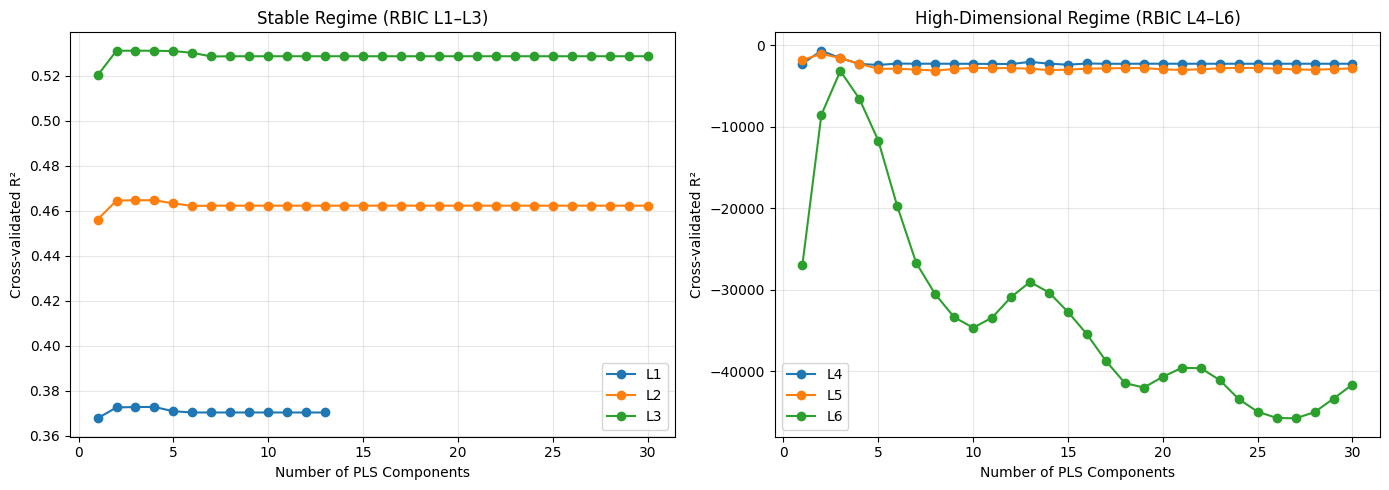

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---- PANEL A: L1–L3 ----
for col in ["L1", "L2", "L3"]:
    axes[0].plot(results_df.index, results_df[col], marker="o", label=col)

axes[0].set_title("Stable Regime (RBIC L1–L3)")
axes[0].set_xlabel("Number of PLS Components")
axes[0].set_ylabel("Cross-validated R²")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- PANEL B: L4–L6 ----
for col in ["L4", "L5", "L6"]:
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col)

axes[1].set_title("High-Dimensional Regime (RBIC L4–L6)")
axes[1].set_xlabel("Number of PLS Components")
axes[1].set_ylabel("Cross-validated R²")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Extract best R² and corresponding K
summary = []

for col in results_df.columns:

    series = results_df[col].dropna()

    best_r2 = series.max()
    best_k = series.idxmax()

    summary.append({
        "Level": col,
        "Best_R2": best_r2,
        "Best_K": best_k
    })

summary_df = pd.DataFrame(summary)

summary_df

,Level,Best_R2,Best_K
0,L1,0.372853,4
1,L2,0.464741,3
2,L3,0.531187,3
3,L4,-654.761741,2
4,L5,-1053.390232,2
5,L6,-3137.955707,3


Test

In [ ]:

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

# ----------------------------
# 1. CROSS-VALIDATION SETUP
# ----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ----------------------------
# 2. TARGET VARIABLE (ALIGNMENT)
# ----------------------------
y = df.groupby("clarity_id")["log_emissions"].mean()

# ----------------------------
# 3. RBIC FEATURE MATRIX (L3)
# ----------------------------
X_rbic = df.pivot_table(
    index="clarity_id",
    columns="l3_id",
    values="value",
    aggfunc="sum",
    fill_value=0
)

# ----------------------------
# 4. ALIGN X AND Y (CRITICAL STEP)
# ----------------------------
common_index = X_rbic.index.intersection(y.index)

X_rbic = X_rbic.loc[common_index]
y = y.loc[common_index]

# ----------------------------
# 5. MODELS
# ----------------------------

# RBIC baseline model (no dimensionality reduction)
rbic_model = Ridge(alpha=1.0)

# PLS model (latent representation + regression)
pls_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("pls", PLSRegression(n_components=3))
])

# ----------------------------
# 6. EVALUATION FUNCTION
# ----------------------------
def evaluate(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    return np.mean(scores), np.std(scores)

# ----------------------------
# 7. RUN COMPARISON
# ----------------------------
results = {}

rbic_mean, rbic_std = evaluate(rbic_model, X_rbic, y, kf)
pls_mean, pls_std = evaluate(pls_model, X_rbic, y, kf)

results["RBIC_L3"] = {"R2_mean": rbic_mean, "R2_std": rbic_std}
results["PLS_L3"] = {"R2_mean": pls_mean, "R2_std": pls_std}

# ----------------------------
# 8. DISPLAY RESULTS
# ----------------------------
results_df = pd.DataFrame(results).T
results_df

,R2_mean,R2_std
RBIC_L3,0.528745,0.013440
PLS_L3,0.531187,0.012382


## Clustering

In [ ]:
best_level = results_df.mean().idxmax()
best_k = results_df[best_level].idxmax()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
def kmeans_sweep(Z, k_range=range(2, 21), random_state=42):
    inertia = []
    silhouette = []
    models = []

    for k in k_range:
        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            random_state=random_state
        )

        labels = km.fit_predict(Z)

        inertia.append(km.inertia_)
        silhouette.append(silhouette_score(Z, labels))
        models.append(km)

    return inertia, silhouette, models

In [ ]:
k_range = range(2, 30)

inertia, silhouette, models = kmeans_sweep(Z, k_range)

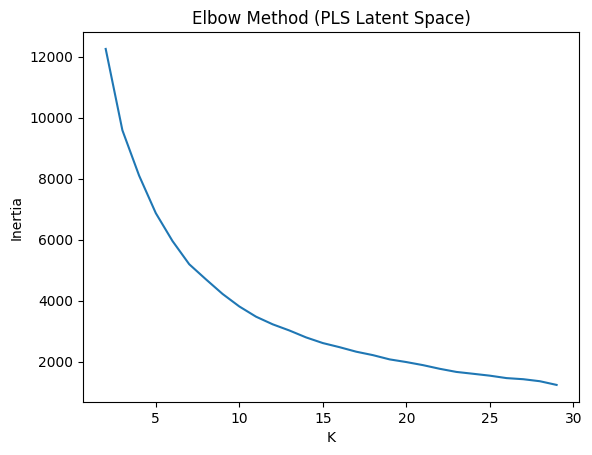

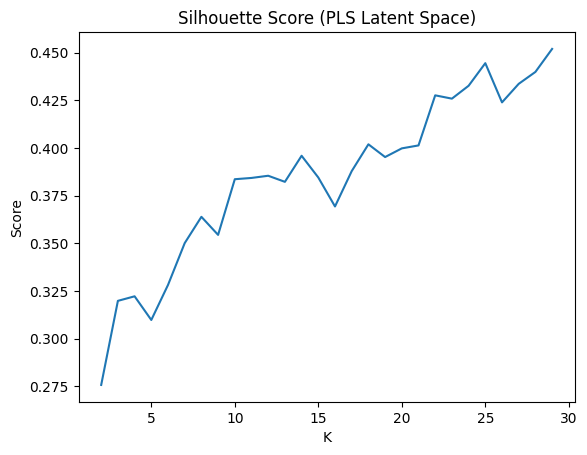

In [ ]:
plt.figure()
plt.plot(k_range, inertia)
plt.title("Elbow Method (PLS Latent Space)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(k_range, silhouette)
plt.title("Silhouette Score (PLS Latent Space)")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

Testing with much higher K values

In [ ]:
def kmeans_sweep_highK(Z, k_range=range(2, 501), random_state=42, silhouette_sample=5000):

    inertia = []
    silhouette = []
    ks = []

    for k in k_range:
        print(f"Running K={k}")

        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=random_state,
            algorithm="lloyd"
        )

        labels = km.fit_predict(Z)

        inertia.append(km.inertia_)
        ks.append(k)

        # --- Silhouette (subsample for speed if dataset is large) ---
        if len(Z) > silhouette_sample:
            idx = np.random.choice(len(Z), silhouette_sample, replace=False)
            sil = silhouette_score(Z[idx], labels[idx])
        else:
            sil = silhouette_score(Z, labels)

        silhouette.append(sil)

    return ks, inertia, silhouette

In [ ]:
k_range = np.unique(
    np.round(np.logspace(np.log10(2), np.log10(3000), 60)).astype(int)
)

ks, inertia, silhouette = kmeans_sweep_highK(Z, k_range)

Running K=2
Running K=3
Running K=4
Running K=5
Running K=6
Running K=7
Running K=8
Running K=9
Running K=10
Running K=11
Running K=13
Running K=15
Running K=16
Running K=19
Running K=21
Running K=24
Running K=27
Running K=31
Running K=35
Running K=39
Running K=44
Running K=50
Running K=57
Running K=64
Running K=73
Running K=82
Running K=93
Running K=106
Running K=120
Running K=135
Running K=153
Running K=173
Running K=196
Running K=222
Running K=251
Running K=285
Running K=322
Running K=365
Running K=413
Running K=467
Running K=529
Running K=599
Running K=678
Running K=767
Running K=869
Running K=983
Running K=1113
Running K=1260
Running K=1426
Running K=1614
Running K=1827
Running K=2068
Running K=2341
Running K=2650
Running K=3000


In [ ]:
np.unique(
    np.round(np.logspace(np.log10(2), np.log10(3000), 60)).astype(int)
)

array([   2,    3,    4,    5,    6,    7,    8,    9,   10,   11,   13,
         15,   16,   19,   21,   24,   27,   31,   35,   39,   44,   50,
         57,   64,   73,   82,   93,  106,  120,  135,  153,  173,  196,
        222,  251,  285,  322,  365,  413,  467,  529,  599,  678,  767,
        869,  983, 1113, 1260, 1426, 1614, 1827, 2068, 2341, 2650, 3000])

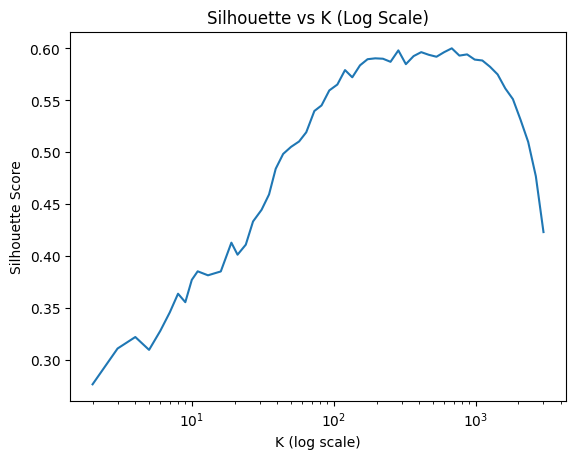

In [ ]:
plt.figure()
plt.plot(ks, silhouette)
plt.xscale("log")
plt.xlabel("K (log scale)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs K (Log Scale)")
plt.show()

In [ ]:
def refine_silhouette_peak(Z, k_min=500, k_max=1000, step=25, random_state=42, sample_size=5000):

    ks = np.arange(k_min, k_max + 1, step)

    sil_scores = []

    for k in ks:
        print(f"K={k}")

        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=random_state
        )

        labels = km.fit_predict(Z)

        # optional subsampling for speed/stability
        if len(Z) > sample_size:
            idx = np.random.choice(len(Z), sample_size, replace=False)
            sil = silhouette_score(Z[idx], labels[idx])
        else:
            sil = silhouette_score(Z, labels)

        sil_scores.append(sil)

    return ks, np.array(sil_scores)

In [ ]:
ks_refined, sil_refined = refine_silhouette_peak(Z)

K=500
K=525
K=550
K=575
K=600
K=625
K=650
K=675
K=700
K=725
K=750
K=775
K=800
K=825
K=850
K=875
K=900
K=925
K=950
K=975
K=1000


In [ ]:
from scipy.ndimage import gaussian_filter1d

sil_smooth = gaussian_filter1d(sil_refined, sigma=2)

In [ ]:
peak_idx = np.argmax(sil_smooth)
k_star = ks_refined[peak_idx]
peak_value = sil_smooth[peak_idx]

print("Optimal K:", k_star)
print("Silhouette:", peak_value)

Optimal K: 700
Silhouette: 0.5983059780302091


In [ ]:
threshold = 0.99 * peak_value  # 99% of peak

stable_region = ks_refined[sil_smooth >= threshold]

k_min_star = stable_region.min()
k_max_star = stable_region.max()

print("Stable K range:", k_min_star, "-", k_max_star)

Stable K range: 500 - 900


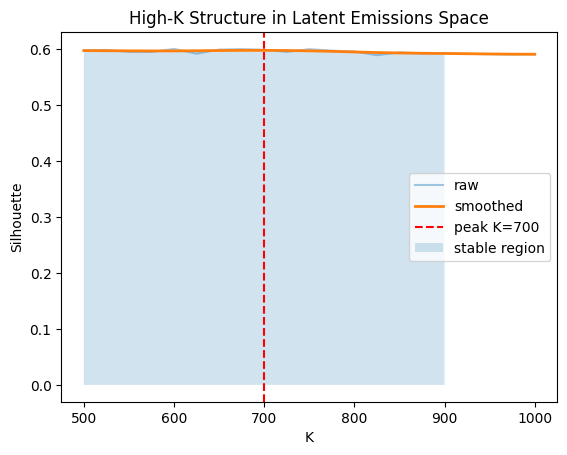

In [ ]:
plt.figure()
plt.plot(ks_refined, sil_refined, alpha=0.4, label="raw")
plt.plot(ks_refined, sil_smooth, label="smoothed", linewidth=2)

plt.axvline(k_star, color="red", linestyle="--", label=f"peak K={k_star}")

plt.fill_between(
    ks_refined,
    sil_smooth,
    where=(sil_smooth >= threshold),
    alpha=0.2,
    label="stable region"
)

plt.xlabel("K")
plt.ylabel("Silhouette")
plt.title("High-K Structure in Latent Emissions Space")
plt.legend()
plt.show()

# Tests

In [ ]:
def build_rbic_matrix(df, level_col):
    X = df.pivot_table(
        index="clarity_id",
        columns=level_col,
        values="value",
        aggfunc="sum",
        fill_value=0
    )
    return X

In [ ]:
X=build_rbic_matrix(df,'l3_id')

In [ ]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

# -----------------------------
# Assumes you already have:
# X, y_aligned, best_k, Z
# -----------------------------

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate_model(model, X, y, name, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    r2 = cross_val_score(model, X, y, cv=kf, scoring="r2")
    rmse = -cross_val_score(
        model, X, y, cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    print(f"{name}")
    print(f"  R²   : {r2.mean():.4f} ± {r2.std():.4f}")
    print(f"  RMSE : {rmse.mean():.4f} ± {rmse.std():.4f}\n")

    return r2, rmse


# -----------------------------
# (A) Baseline: PLS on X
# -----------------------------
pls_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("pls", PLSRegression(n_components=3))
])

evaluate_model(pls_model, X, y_aligned, "PLS baseline (X → y)")


# -----------------------------
# (B) Latent space: Z → y
# -----------------------------
ridge_Z = Ridge(alpha=1.0)
evaluate_model(ridge_Z, Z, y_aligned, "Latent space (Z → y)")


# -----------------------------
# (C) Clustering on Z
# -----------------------------
kmeans = KMeans(n_clusters=500, n_init="auto", random_state=42)
clusters = kmeans.fit_predict(Z)

encoder = OneHotEncoder(sparse_output=False)
C = encoder.fit_transform(clusters.reshape(-1, 1))

ridge_C = Ridge(alpha=1.0)
evaluate_model(ridge_C, C, y_aligned, "Clusters only (C → y)")


# -----------------------------
# (D) Hybrid: Z + clusters
# -----------------------------
ZC = np.hstack([Z, C])

ridge_ZC = Ridge(alpha=1.0)
evaluate_model(ridge_ZC, ZC, y_aligned, "Hybrid (Z + C → y)")

PLS baseline (X → y)
  R²   : 0.5312 ± 0.0124
  RMSE : 0.6824 ± 0.0114

Latent space (Z → y)
  R²   : 0.5508 ± 0.0094
  RMSE : 0.6679 ± 0.0093

Clusters only (C → y)
  R²   : 0.4895 ± 0.0132
  RMSE : 0.7121 ± 0.0098

Hybrid (Z + C → y)
  R²   : 0.5225 ± 0.0110
  RMSE : 0.6886 ± 0.0099



(array([0.50532803, 0.52159094, 0.52419119, 0.53990199, 0.52161913]),
 array([0.67217624, 0.6923509 , 0.70106643, 0.68392528, 0.69366998]))

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge

kf = KFold(n_splits=5, shuffle=True, random_state=42)


# =========================================================
# FUNCTION: predictive R²
# =========================================================
def predictive_r2(X, y, name):
    model = Ridge(alpha=1.0)

    r2 = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print(f"{name}")
    print(f"  R²: {r2.mean():.4f} ± {r2.std():.4f}\n")

    return r2


# =========================================================
# 1. RBICS (predictive)
# =========================================================
from sklearn.preprocessing import OneHotEncoder

rbics_col = "l3_id"

rbics_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_rbics = rbic_dominant[rbics_col].astype(str).values.reshape(-1, 1)

X_rbics = rbics_encoder.fit_transform(X_rbics)

rbics_r2 = predictive_r2(X_rbics, y_aligned, "RBICS predictive (L3 → y)")



rbics_col = "l6_id"

rbics_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_rbics = rbic_dominant[rbics_col].astype(str).values.reshape(-1, 1)

X_rbics = rbics_encoder.fit_transform(X_rbics)

rbics_r2 = predictive_r2(X_rbics, y_aligned, "RBICS predictive (L6 → y)")




# =========================================================
# 2. GICS (predictive)
# =========================================================
from sklearn.preprocessing import OneHotEncoder

# -----------------------------
# Select correct column name
# -----------------------------
gics_col = "gics_subindustry_name"   # or change to group/industry/subindustry

# -----------------------------
# One-hot encoding
# -----------------------------
gics_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_gics = scope_gics[gics_col].astype(str).values.reshape(-1, 1)

X_gics = gics_encoder.fit_transform(X_gics)

# -----------------------------
# Predictive R² evaluation
# -----------------------------
gics_r2 = predictive_r2(
    X_gics,
    y_aligned,
    "GICS predictive (Subindustry → y)"
)

RBICS predictive (L3 → y)
  R²: 0.5074 ± 0.0148

RBICS predictive (L6 → y)
  R²: 0.5460 ± 0.0259

GICS predictive (Sector → y)
  R²: -0.0383 ± 0.0144



In [ ]:
pls_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=10))
])

pls_r2 = cross_val_score(pls_model, X, y_aligned, cv=kf, scoring="r2")

print("PLS (X → y)")
print(f"  R²: {pls_r2.mean():.4f} ± {pls_r2.std():.4f}\n")


# =========================================================
# 4. YOUR METHOD (Z latent space)
# =========================================================
ridge_z = Ridge(alpha=1.0)

z_r2 = cross_val_score(ridge_z, Z, y_aligned, cv=kf, scoring="r2")

print("PLS latent space (Z → y)")
print(f"  R²: {z_r2.mean():.4f} ± {z_r2.std():.4f}\n")

PLS (X → y)
  R²: 0.5287 ± 0.0135

PLS latent space (Z → y)
  R²: 0.5508 ± 0.0094



# Step 3 reworked: unified 3-parameter sweep

This section replaces the sequential decision process of the original Step 3 with a
single, joint optimisation over three parameters:

1. **RBIC level** (`l1_id` ... `l6_id`) — granularity of the economic activity features.
2. **`K_pls`** — number of PLS latent components (model complexity of the supervised
   dimensionality reduction).
3. **`K_cluster`** — number of KMeans clusters used to discretise the latent space.

Instead of selecting each parameter separately by different criteria (R² for the first
two, silhouette/elbow for the third), we evaluate every combination on the same
downstream objective — **cross-validated R²** — so that the three choices interact.

**What is reported at every grid point.** For each triple `(level, K_pls, K_cluster)`
we compute three cross-validated R² values, all on the same 5 folds:

* `R²_Z`  — Ridge regression of `Z → y` (PLS latent only; independent of `K_cluster`).
* `R²_C`  — Ridge regression of one-hot cluster labels `C → y`.
* `R²_ZC` — Ridge regression of the concatenation `[Z, C] → y` (hybrid).

**Optimisation target.** `R²_C` — this is the apples-to-apples metric against
GICS / RBIC one-hot R² from Steps 1–2 (it represents the predictive value of the
discrete classification that the pipeline produces). `R²_Z` acts as an upper-bound
reference and `R²_ZC` as a "what if we relaxed the discrete constraint" reference.

**Correctness note.** Unlike the prior implementation, PLS **and** KMeans are refit
*inside every CV fold*. The previous code fit them once on the full data and only
cross-validated the final Ridge step, which leaks information through the PLS and
KMeans parameters.

In [ ]:
# ---------------------------------------------------------------------------
# Step 3 reworked — imports and CV setup
# ---------------------------------------------------------------------------
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

CV_SEED = 42
N_SPLITS = 5
RIDGE_ALPHA = 1.0

kf_main = KFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

In [ ]:
# ---------------------------------------------------------------------------
# Pre-build aligned (X, y) arrays for every RBIC level once.
# This avoids repivoting the long `df` table inside the sweep.
# ---------------------------------------------------------------------------
def build_rbic_matrix_v2(df_long, level_col):
    return df_long.pivot_table(
        index="clarity_id",
        columns=level_col,
        values="value",
        aggfunc="sum",
        fill_value=0
    )

# Target: log emissions intensity per company
_y_series = df.groupby("clarity_id")["log_emissions"].mean()

rbic_levels_all = ["l1_id", "l2_id", "l3_id", "l4_id", "l5_id", "l6_id"]
level_label     = {f"l{i}_id": f"L{i}" for i in range(1, 7)}

prebuilt = {}

for lvl in rbic_levels_all:
    Xdf    = build_rbic_matrix_v2(df, lvl)
    common = Xdf.index.intersection(_y_series.index)

    X_arr = Xdf.loc[common].sort_index().to_numpy(dtype=float)
    y_arr = _y_series.loc[common].sort_index().to_numpy(dtype=float).ravel()

    prebuilt[lvl] = (X_arr, y_arr)
    print(f"{level_label[lvl]}: X={X_arr.shape}, y={y_arr.shape}")

In [ ]:
# ---------------------------------------------------------------------------
# Core evaluator: for a fixed (level, K_pls), sweep K_cluster within the same
# precomputed per-fold PLS scores so that PLS is only fit N_SPLITS times per
# (level, K_pls) pair instead of N_SPLITS * len(K_cluster_list) times.
# ---------------------------------------------------------------------------

def _kmeans_for_K(K, random_state=CV_SEED, minibatch_threshold=400):
    """Exact KMeans for small K, MiniBatchKMeans for large K (where exact
    KMeans becomes the dominant cost of the sweep)."""
    if K >= minibatch_threshold:
        return MiniBatchKMeans(
            n_clusters=K,
            n_init=3,
            random_state=random_state,
            batch_size=1024,
            max_iter=100,
        )
    return KMeans(
        n_clusters=K,
        n_init=3,
        random_state=random_state,
        algorithm="lloyd",
    )


def _precompute_folds(X_full, y_full, K_pls, kf):
    """Fit scaler + PLS inside every fold; return list of
    (Z_tr, Z_te, y_tr, y_te). Returns None if K_pls is infeasible."""
    folds = []
    for tr_idx, te_idx in kf.split(X_full):
        X_tr, X_te = X_full[tr_idx], X_full[te_idx]
        y_tr, y_te = y_full[tr_idx], y_full[te_idx]

        scaler  = StandardScaler(with_mean=False)
        X_tr_s  = scaler.fit_transform(X_tr)
        X_te_s  = scaler.transform(X_te)

        feasible_K = min(K_pls, X_tr_s.shape[0] - 1, X_tr_s.shape[1])
        if feasible_K < 1:
            return None

        pls  = PLSRegression(n_components=feasible_K, scale=False)
        pls.fit(X_tr_s, y_tr)
        Z_tr = pls.transform(X_tr_s)
        Z_te = pls.transform(X_te_s)

        folds.append((Z_tr, Z_te, y_tr, y_te))
    return folds


def evaluate_level_kpls(X_full, y_full, K_pls, K_cluster_list, kf,
                        ridge_alpha=RIDGE_ALPHA):
    """Full CV evaluation for a fixed (level, K_pls) across all K_cluster
    values. Returns a list of per-row dicts."""

    folds = _precompute_folds(X_full, y_full, K_pls, kf)
    if folds is None:
        return []

    # R^2_Z is constant across K_cluster values at fixed K_pls, so
    # compute it once.
    r2_Z_folds = []
    for Z_tr, Z_te, y_tr, y_te in folds:
        rZ = Ridge(alpha=ridge_alpha).fit(Z_tr, y_tr)
        r2_Z_folds.append(r2_score(y_te, rZ.predict(Z_te)))
    R2_Z_mean = float(np.mean(r2_Z_folds))
    R2_Z_std  = float(np.std(r2_Z_folds))

    rows = []
    for K_cluster in K_cluster_list:
        r2_C_folds, r2_ZC_folds = [], []
        for Z_tr, Z_te, y_tr, y_te in folds:
            K_eff = min(int(K_cluster), Z_tr.shape[0])
            km    = _kmeans_for_K(K_eff)
            km.fit(Z_tr)
            lab_tr = km.predict(Z_tr)
            lab_te = km.predict(Z_te)

            enc  = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            C_tr = enc.fit_transform(lab_tr.reshape(-1, 1))
            C_te = enc.transform(lab_te.reshape(-1, 1))

            rC = Ridge(alpha=ridge_alpha).fit(C_tr, y_tr)
            r2_C_folds.append(r2_score(y_te, rC.predict(C_te)))

            ZC_tr = np.hstack([Z_tr, C_tr])
            ZC_te = np.hstack([Z_te, C_te])
            rZC   = Ridge(alpha=ridge_alpha).fit(ZC_tr, y_tr)
            r2_ZC_folds.append(r2_score(y_te, rZC.predict(ZC_te)))

        rows.append({
            "K_pls":      K_pls,
            "K_cluster":  int(K_cluster),
            "R2_Z_mean":  R2_Z_mean,
            "R2_Z_std":   R2_Z_std,
            "R2_C_mean":  float(np.mean(r2_C_folds)),
            "R2_C_std":   float(np.std(r2_C_folds)),
            "R2_ZC_mean": float(np.mean(r2_ZC_folds)),
            "R2_ZC_std":  float(np.std(r2_ZC_folds)),
        })
    return rows

In [ ]:
# ---------------------------------------------------------------------------
# Sweep driver
# ---------------------------------------------------------------------------

def run_unified_sweep(prebuilt, level_label, K_pls_list, K_cluster_list,
                      kf, verbose=True):
    all_rows = []
    t_global = time.time()

    for lvl, (X_arr, y_arr) in prebuilt.items():
        n_features = X_arr.shape[1]
        for K_pls in K_pls_list:
            if K_pls > n_features:
                continue
            t0 = time.time()
            rows = evaluate_level_kpls(
                X_arr, y_arr, K_pls, K_cluster_list, kf
            )
            for r in rows:
                r["level"]     = level_label[lvl]
                r["level_col"] = lvl
            all_rows.extend(rows)
            if verbose:
                print(
                    f"  {level_label[lvl]}  K_pls={K_pls:>2}  "
                    f"-> {len(rows)} K_cluster pts in "
                    f"{time.time() - t0:6.1f}s"
                )
        if verbose:
            print(
                f"== {level_label[lvl]} done (cumulative "
                f"{(time.time() - t_global)/60:.1f} min) =="
            )

    return pd.DataFrame(all_rows)

In [ ]:
# ---------------------------------------------------------------------------
# Define the grid and run the sweep.
#
# Tune these lists to your compute budget. Expected cost scales roughly with
#     sum_over_levels( n_K_pls_feasible_at_level ) * len(K_cluster_grid) * N_SPLITS
# with the KMeans step at large K_cluster dominating.
# ---------------------------------------------------------------------------

K_pls_grid = [1, 2, 3, 5, 8, 12, 20]

# Wide log-spaced K_cluster grid, 2 -> 3000 (same scheme used in the original
# high-K silhouette sweep).
K_cluster_grid = np.unique(
    np.round(np.logspace(np.log10(2), np.log10(3000), 30)).astype(int)
).tolist()

print("K_pls grid     :", K_pls_grid)
print("K_cluster grid :", K_cluster_grid)
print(
    "Max grid size  :",
    6 * len(K_pls_grid) * len(K_cluster_grid),
    "points"
)

In [ ]:
# Run the unified 3D sweep. This cell is the expensive one; expect tens of
# minutes at the default grid. Progress is printed per (level, K_pls).
results_3d = run_unified_sweep(
    prebuilt       = prebuilt,
    level_label    = level_label,
    K_pls_list     = K_pls_grid,
    K_cluster_list = K_cluster_grid,
    kf             = kf_main,
    verbose        = True,
)

print(f"\nTotal grid points evaluated: {len(results_3d)}")
results_3d.head()

In [ ]:
# ---------------------------------------------------------------------------
# Locate the best grid point under each of the three objectives.
# The chosen optimisation target of the thesis is R^2_C (clusters only).
# ---------------------------------------------------------------------------

def _report_best(results_df, metric, label):
    best = results_df.loc[results_df[metric].idxmax()]
    std_col = metric.replace("mean", "std")
    print(f"--- Best by {label} ({metric} = {best[metric]:.4f} ± "
          f"{best[std_col]:.4f}) ---")
    print(
        f"    level={best['level']}  "
        f"K_pls={int(best['K_pls'])}  "
        f"K_cluster={int(best['K_cluster'])}"
    )
    print()

print("=== BEST POINT UNDER EACH OBJECTIVE ===\n")
_report_best(results_3d, "R2_C_mean",  "R^2_C  (Clusters only  C -> y)  [TARGET]")
_report_best(results_3d, "R2_ZC_mean", "R^2_ZC (Hybrid        Z+C -> y)")
_report_best(results_3d, "R2_Z_mean",  "R^2_Z  (Latent only     Z -> y)")

# Canonical optimum: max R^2_C
best_row = results_3d.loc[results_3d["R2_C_mean"].idxmax()]

optimal_config = {
    "level":      best_row["level"],
    "level_col":  best_row["level_col"],
    "K_pls":      int(best_row["K_pls"]),
    "K_cluster":  int(best_row["K_cluster"]),
    "R2_C_mean":  float(best_row["R2_C_mean"]),
    "R2_C_std":   float(best_row["R2_C_std"]),
    "R2_Z_mean":  float(best_row["R2_Z_mean"]),
    "R2_ZC_mean": float(best_row["R2_ZC_mean"]),
}
print("OPTIMAL CONFIG (target = R^2_C):")
for k, v in optimal_config.items():
    print(f"  {k:12s}: {v}")

In [ ]:
# ---------------------------------------------------------------------------
# Heatmap of R^2_C over (K_pls, K_cluster) at the best level.
# ---------------------------------------------------------------------------
best_level = optimal_config["level"]
sub = results_3d[results_3d["level"] == best_level]

heat = sub.pivot_table(
    index="K_pls",
    columns="K_cluster",
    values="R2_C_mean",
)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat.values, aspect="auto", origin="lower", cmap="viridis")
fig.colorbar(im, ax=ax, label="CV R²_C")

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

# Mark the optimum
if optimal_config["K_pls"] in heat.index and optimal_config["K_cluster"] in heat.columns:
    xi = list(heat.columns).index(optimal_config["K_cluster"])
    yi = list(heat.index).index(optimal_config["K_pls"])
    ax.plot(xi, yi, marker="*", markersize=18, color="red",
            markeredgecolor="white", linewidth=0)

ax.set_xlabel("K_cluster")
ax.set_ylabel("K_pls")
ax.set_title(f"R²_C heatmap at level {best_level}  (★ = optimum)")
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# For each RBIC level, show R^2_C vs K_cluster at that level's best K_pls.
# ---------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

for lvl_label in ["L1", "L2", "L3", "L4", "L5", "L6"]:
    sub = results_3d[results_3d["level"] == lvl_label]
    if sub.empty:
        continue
    best_kpls = sub.groupby("K_pls")["R2_C_mean"].max().idxmax()
    s = sub[sub["K_pls"] == best_kpls].sort_values("K_cluster")
    plt.plot(
        s["K_cluster"], s["R2_C_mean"],
        marker="o",
        label=f"{lvl_label}  (best K_pls={best_kpls})",
    )

plt.xscale("log")
plt.xlabel("K_cluster (log scale)")
plt.ylabel("CV R²_C (Clusters -> y)")
plt.title("Cluster-only predictive power across RBIC levels")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# At the optimal (level, K_pls), compare the three objectives as a function
# of K_cluster. Shows the trade-off the sweep is navigating.
# ---------------------------------------------------------------------------
sub_best = results_3d[
    (results_3d["level"] == optimal_config["level"])
    & (results_3d["K_pls"] == optimal_config["K_pls"])
].sort_values("K_cluster")

plt.figure(figsize=(10, 6))
plt.plot(sub_best["K_cluster"], sub_best["R2_Z_mean"],
         marker="o", label="Z -> y   (latent only)")
plt.plot(sub_best["K_cluster"], sub_best["R2_C_mean"],
         marker="s", label="C -> y   (clusters only)  [target]")
plt.plot(sub_best["K_cluster"], sub_best["R2_ZC_mean"],
         marker="^", label="Z+C -> y (hybrid)")

plt.axvline(
    optimal_config["K_cluster"],
    color="red", linestyle="--", alpha=0.5,
    label=f"K_cluster* = {optimal_config['K_cluster']}",
)
plt.xscale("log")
plt.xlabel("K_cluster (log scale)")
plt.ylabel("CV R²")
plt.title(
    f"All three objectives at level {optimal_config['level']}, "
    f"K_pls={optimal_config['K_pls']}"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpreting the sweep

* The **heatmap** shows the full `(K_pls, K_cluster)` surface at the level the sweep
  selected. Look for whether the optimum is on a plateau (robust) or a sharp peak
  (fragile / overfit to this CV split).
* The **slice plot across levels** shows whether the classical "L3 is the sweet spot"
  observation from the sequential procedure survives once clustering cost is
  accounted for jointly, or whether the optimum migrates (e.g. L4 with modest
  `K_cluster` may beat L3 with very large `K_cluster`).
* The **three-R² comparison** isolates the cost of the discretisation: the gap
  `R²_Z − R²_C` measures how much signal clustering throws away, while
  `R²_ZC` shows how much of that gap the continuous dimensions can recover.

If `R²_C` keeps rising with `K_cluster` until overfitting kicks in, the data wants a
fine-grained classification. If `R²_C` plateaus early, a coarse industry-scale
taxonomy is already sufficient.

## Persisting the sweep results

The grid sweep is the expensive step of the thesis: tens of minutes of compute
per run, and the exact numbers depend on CV seed, RBIC release tag, and
sklearn version. To make sure the sweep is **run-once**, the cells below
save everything needed to never run it again:

* `results_3d` — the full 3-D grid DataFrame (every `(level, K_pls, K_cluster)` row
  with its three R²s).
* A **metadata JSON** recording the grid definition, the CV seed, the Ridge alpha,
  the release tag, and the date of the run — so the numbers are reproducible
  and self-documenting months later.
* The **refitted optimal pipeline**: the `StandardScaler`, `PLSRegression`, and
  `KMeans`/`MiniBatchKMeans` fitted on the *entire* sample at the best
  `(level, K_pls, K_cluster)` configuration. These are the objects you will
  call `.transform` / `.predict` on for any downstream analysis.
* A **per-company table** with each firm's latent Z coordinates and cluster label,
  ready to merge with the GICS / RBIC / emissions dataframes for comparison.

Everything is written to your Google Drive under `Colab Notebooks/TFG_results/`
with a timestamped run tag plus a `*_latest.*` alias that always points at the
most recent successful save.

In [ ]:
# ---------------------------------------------------------------------------
# Save the sweep results, the refitted optimal model, and the per-company
# outputs to Google Drive. Run once after the sweep finishes.
# ---------------------------------------------------------------------------
import os, json, joblib
from datetime import datetime

# Location on Drive. Change this one line if you want a different folder.
SAVE_DIR = f"{home_dir}TFG_results"
os.makedirs(SAVE_DIR, exist_ok=True)

run_tag = f"sweep_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
print(f"Writing to: {SAVE_DIR}")
print(f"Run tag:    {run_tag}")

# --- (A) the sweep DataFrame --------------------------------------------------
results_3d.to_csv    (f"{SAVE_DIR}/{run_tag}_results.csv",     index=False)
results_3d.to_parquet(f"{SAVE_DIR}/{run_tag}_results.parquet", index=False)
# "latest" aliases for convenience
results_3d.to_csv    (f"{SAVE_DIR}/results_latest.csv",     index=False)
results_3d.to_parquet(f"{SAVE_DIR}/results_latest.parquet", index=False)

# --- (B) metadata -------------------------------------------------------------
metadata = {
    "run_tag":        run_tag,
    "timestamp":      datetime.now().isoformat(),
    "release_tag":    release_tag,
    "n_companies":    int(len(_y_series)),
    "n_grid_points":  int(len(results_3d)),
    "K_pls_grid":     list(map(int, K_pls_grid)),
    "K_cluster_grid": list(map(int, K_cluster_grid)),
    "rbic_levels":    rbic_levels_all,
    "N_SPLITS":       int(N_SPLITS),
    "CV_SEED":        int(CV_SEED),
    "RIDGE_ALPHA":    float(RIDGE_ALPHA),
    "optimal_config": {k: (float(v) if isinstance(v, (int, float)) else v)
                       for k, v in optimal_config.items()},
}
with open(f"{SAVE_DIR}/{run_tag}_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)
with open(f"{SAVE_DIR}/metadata_latest.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

# --- (C) refit optimal pipeline on ALL data -----------------------------------
# This produces ready-to-use model objects and per-company Z / cluster outputs.
opt_level_col = optimal_config["level_col"]
opt_K_pls     = int(optimal_config["K_pls"])
opt_K_cluster = int(optimal_config["K_cluster"])

# Rebuild the pivoted matrix at the optimal level, this time keeping the
# company IDs around so we can attach them to the outputs.
Xdf_opt = build_rbic_matrix_v2(df, opt_level_col)
common  = Xdf_opt.index.intersection(_y_series.index)
Xdf_opt = Xdf_opt.loc[common].sort_index()
y_opt   = _y_series.loc[common].sort_index()
company_ids = Xdf_opt.index.to_numpy()

X_opt    = Xdf_opt.to_numpy(dtype=float)
y_opt_np = y_opt.to_numpy(dtype=float).ravel()

scaler_final = StandardScaler(with_mean=False)
X_opt_s      = scaler_final.fit_transform(X_opt)

pls_final = PLSRegression(n_components=opt_K_pls, scale=False)
pls_final.fit(X_opt_s, y_opt_np)
Z_full = pls_final.transform(X_opt_s)

km_final = _kmeans_for_K(opt_K_cluster)
km_final.fit(Z_full)
labels_full = km_final.predict(Z_full)

# --- (D) per-company table ----------------------------------------------------
per_company = pd.DataFrame({
    "clarity_id":    company_ids,
    "log_emissions": y_opt_np,
    "cluster":       labels_full,
})
for i in range(Z_full.shape[1]):
    per_company[f"Z{i+1}"] = Z_full[:, i]

per_company.to_csv    (f"{SAVE_DIR}/{run_tag}_per_company.csv",     index=False)
per_company.to_parquet(f"{SAVE_DIR}/{run_tag}_per_company.parquet", index=False)
per_company.to_parquet(f"{SAVE_DIR}/per_company_latest.parquet",   index=False)

# --- (E) fitted sklearn objects ----------------------------------------------
bundle = {
    "scaler":  scaler_final,
    "pls":     pls_final,
    "kmeans":  km_final,
    "config":  optimal_config,
    "feature_names": list(Xdf_opt.columns),  # lets you align new data
}
joblib.dump(bundle, f"{SAVE_DIR}/{run_tag}_models.joblib")
joblib.dump(bundle, f"{SAVE_DIR}/models_latest.joblib")

# --- summary ------------------------------------------------------------------
print("\n=== SAVED ===")
print(f"  {run_tag}_results.csv / .parquet      ({len(results_3d)} rows)")
print(f"  {run_tag}_metadata.json")
print(f"  {run_tag}_per_company.csv / .parquet ({len(per_company)} rows)")
print(f"  {run_tag}_models.joblib")
print()
print("  results_latest.csv / .parquet   (alias of the run above)")
print("  metadata_latest.json")
print("  per_company_latest.parquet")
print("  models_latest.joblib")
print()
print(f"Optimal config: level={optimal_config['level']}  "
      f"K_pls={opt_K_pls}  K_cluster={opt_K_cluster}  "
      f"R²_C={optimal_config['R2_C_mean']:.4f}")

### Reloading without re-running the sweep

In any future session, after the notebook has executed cells 1–N (Drive mount,
Snowflake connectors, data loading, the `df` dataframe construction) and the
small setup cells of Step 3 reworked (imports, `build_rbic_matrix_v2`, the
`_kmeans_for_K` helper), you can run the cell below **instead of** the sweep
cell to pull everything back from Drive in a second or two.

Toggle `SKIP_SWEEP = True` when you want to reload, `False` when you want to
force a fresh sweep.

In [ ]:
# ---------------------------------------------------------------------------
# Reload cached sweep results from Drive. Set SKIP_SWEEP=False to redo the
# sweep from scratch.
# ---------------------------------------------------------------------------
import os, json, joblib

SKIP_SWEEP = True
SAVE_DIR   = f"{home_dir}TFG_results"

if SKIP_SWEEP and os.path.exists(f"{SAVE_DIR}/results_latest.parquet"):
    results_3d  = pd.read_parquet(f"{SAVE_DIR}/results_latest.parquet")
    per_company = pd.read_parquet(f"{SAVE_DIR}/per_company_latest.parquet")

    with open(f"{SAVE_DIR}/metadata_latest.json") as f:
        metadata = json.load(f)
    optimal_config = metadata["optimal_config"]

    bundle       = joblib.load(f"{SAVE_DIR}/models_latest.joblib")
    scaler_final = bundle["scaler"]
    pls_final    = bundle["pls"]
    km_final     = bundle["kmeans"]

    print(f"Loaded cached sweep from {SAVE_DIR}/")
    print(f"  run_tag:         {metadata.get('run_tag', '(none)')}")
    print(f"  timestamp:       {metadata.get('timestamp', '(none)')}")
    print(f"  results_3d:      {len(results_3d)} rows")
    print(f"  per_company:     {len(per_company)} rows")
    print(f"  optimal_config:  {optimal_config}")
else:
    print("SKIP_SWEEP is False (or no cached file found).")
    print("Run the sweep cell above, then the save cell, to populate the cache.")